# 01 · Model Training — Dual-Head BiLSTM-FiLM

*Code execution step below.*

## 0 · Imports & Environment

In [1]:
import utils.plot_csv_exporter
import sys, os, json, logging, warnings
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(name)s — %(message)s')

# Resolve project root.
notebook_dir = Path(os.getcwd()).resolve()
for candidate in [notebook_dir, notebook_dir.parent]:
    if (candidate / 'alibaba_trace' / 'model_architecture.py').exists():
        ALIBABA_DIR = candidate / 'alibaba_trace'
        break
else:
    ALIBABA_DIR = notebook_dir

if str(ALIBABA_DIR) not in sys.path:
    sys.path.insert(0, str(ALIBABA_DIR))

# Module imports.
from model_architecture import (
    build_dual_head_model, DualHeadBiLSTMFiLM, HybridAnomalyLoss,
    build_model,  # kept for comparison
)
from data_pipeline import (
    StreamingMinMaxScaler, build_dataloader,
    FEATURE_COLS, META_COLS, WINDOW_SIZE,
)

print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {torch.device("cuda" if torch.cuda.is_available() else "cpu")}')
print(f'Features : {FEATURE_COLS}')
print('All imports OK — dual-head model loaded.')


PyTorch  : 2.11.0+cpu
Device   : cpu
Features : ['cpu_util_percent', 'mem_util_percent', 'cpu_request', 'mem_request', 'net_in', 'net_out', 'disk_io_percent']
All imports OK — dual-head model loaded.


## 1 · Configuration

In [2]:
# Paths.
OUTPUTS_DIR  = ALIBABA_DIR / 'outputs'
OUTPUTS_DIR.mkdir(exist_ok=True)
MODEL_PATH   = OUTPUTS_DIR / 'dual_head_model.pt'
SCALER_PATH  = OUTPUTS_DIR / 'scaler_params.json'
TAR_PATH     = r'C:\Users\kaspe\Desktop\Project\dataset\data\container_usage.tar.gz'
CSV_MEMBER   = 'container_usage.csv'

# Hyperparameters.
WINDOW       = int(WINDOW_SIZE)    # 50 timesteps per window
N_TS_FEAT    = len(FEATURE_COLS)   # 7 metrics
N_META_FEAT  = len(META_COLS)      # 2 metadata fields
LATENT_DIM   = 64                  # bottleneck size
LSTM_UNITS   = (128, 64)           # BiLSTM hidden units (H1, H2)
FC_HIDDEN    = None                # ForecastingHead hidden (None → 2×latent=128)
DROPOUT      = 0.2
ALPHA        = 0.5                 # reconstruction / forecasting balance

# Training settings.
EPOCHS       = 10
BATCH_SIZE   = 2048
MAX_CHUNKS   = 50                 # Stop ingestion early for speed
LR           = 1e-3
LR_PATIENCE  = 5                   # epochs before LR reduction
EARLY_STOP   = 10                  # epochs before early stopping
TRAIN_RATIO  = 0.85
RANDOM_SEED  = 42

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if DEVICE.type == 'cuda': torch.backends.cudnn.benchmark = True
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Configuration:')
print(f'  ALPHA (α) = {ALPHA}  →  Loss = {ALPHA}·MSE_recon + {1-ALPHA:.1f}·MSE_fore')
print(f'  Latent dim : {LATENT_DIM}')
print(f'  LSTM units : {LSTM_UNITS}')
print(f'  Epochs     : {EPOCHS}  |  Batch : {BATCH_SIZE}  |  LR : {LR}')
print(f'  Device     : {DEVICE}')
print(f'  Model path : {MODEL_PATH}')


Configuration:
  ALPHA (α) = 0.5  →  Loss = 0.5·MSE_recon + 0.5·MSE_fore
  Latent dim : 64
  LSTM units : (128, 64)
  Epochs     : 10  |  Batch : 2048  |  LR : 0.001
  Device     : cpu
  Model path : C:\Users\kaspe\Desktop\Project\project\alibaba_trace\outputs\dual_head_model.pt


## 2 · Scaler Calibration

In [3]:
from pathlib import Path
import json

scaler = StreamingMinMaxScaler(FEATURE_COLS)

if Path(TAR_PATH).exists():
    if SCALER_PATH.exists():
        params = json.load(open(SCALER_PATH))
        scaler.set_params(
            min_=np.array(params['min_'], dtype=np.float32),
            max_=np.array(params['max_'], dtype=np.float32),
        )
        print(f'Scaler loaded from {SCALER_PATH}')
    else:
        scaler.fit(TAR_PATH, CSV_MEMBER, max_chunks=20)
        json.dump({'min_': scaler.min_.tolist(), 'max_': scaler.max_.tolist()},
                  open(SCALER_PATH, 'w'))
        print(f'Scaler fitted and saved to {SCALER_PATH}')
else:
    # Demo mode: use synthetic min/max.
    scaler.set_params(
        min_=np.zeros(N_TS_FEAT, dtype=np.float32),
        max_=np.ones(N_TS_FEAT,  dtype=np.float32) * 100.0,
    )
    print('DEMO mode — synthetic scaler (archive not found).')

print(f'  Min : {scaler.min_.round(3)}')
print(f'  Max : {scaler.max_.round(3)}')


Scaler loaded from C:\Users\kaspe\Desktop\Project\project\alibaba_trace\outputs\scaler_params.json
  Min : [0. 3. 0. 0. 0. 0. 1.]
  Max : [100.   100.     4.07   1.09   3.36   2.26  79.  ]


## 3 · Build Dual-Head Model + Dual-Head DataLoader

*Code execution step below.*

In [4]:
# Instantiate the dual-head model.
model = build_dual_head_model(
    window_size     = WINDOW,
    n_ts_features   = N_TS_FEAT,
    n_meta_features = N_META_FEAT,
    latent_dim      = LATENT_DIM,
    lstm_units      = LSTM_UNITS,
    dropout_rate    = DROPOUT,
    fc_hidden_dim   = FC_HIDDEN,
    device          = DEVICE,
)

# Parameter counts for the thesis table.
n_enc  = sum(p.numel() for p in model.encoder.parameters())
n_film = sum(p.numel() for p in model.film.parameters())
n_rec  = sum(p.numel() for p in model.reconstruction_head.parameters())
n_fore = sum(p.numel() for p in model.forecasting_head.parameters())
n_tot  = n_enc + n_film + n_rec + n_fore

print('Parameter Budget (Dual-Head BiLSTM-FiLM)')
print('─' * 48)
print(f'  Shared Encoder   : {n_enc:>8,}  ({n_enc/n_tot*100:5.1f}%)')
print(f'  FiLM Layer       : {n_film:>8,}  ({n_film/n_tot*100:5.1f}%)')
print(f'  Head 1 Recon     : {n_rec:>8,}  ({n_rec/n_tot*100:5.1f}%)')
print(f'  Head 2 Forecast  : {n_fore:>8,}  ({n_fore/n_tot*100:5.1f}%)')
print(f'  ────────────────────────────────────')
print(f'  Total Trainable  : {n_tot:>8,}')
print()

# Hybrid loss criterion.
criterion = HybridAnomalyLoss(alpha=ALPHA)
print(criterion)

# Optimiser + LR scheduler.
optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=LR_PATIENCE
)

print(f'\nOptimiser : Adam (lr={LR}, weight_decay=1e-5)')
print(f'Scheduler : ReduceLROnPlateau (factor=0.5, patience={LR_PATIENCE})')


2026-04-18 15:27:33,444 [INFO] model_architecture — Built DualHeadBiLSTMFiLM | window=50 | ts_feat=7 | meta_feat=2 | latent=64 | total_params=705,550  (enc=313,920, film=8,512, recon=373,895, fore=9,223)


Parameter Budget (Dual-Head BiLSTM-FiLM)
────────────────────────────────────────────────
  Shared Encoder   :  313,920  ( 44.5%)
  FiLM Layer       :    8,512  (  1.2%)
  Head 1 Recon     :  373,895  ( 53.0%)
  Head 2 Forecast  :    9,223  (  1.3%)
  ────────────────────────────────────
  Total Trainable  :  705,550

HybridAnomalyLoss(alpha=0.5  [recon_weight=0.50, fore_weight=0.50])

Optimiser : Adam (lr=0.001, weight_decay=1e-5)
Scheduler : ReduceLROnPlateau (factor=0.5, patience=5)


## 4 · DataLoader — Dual-Head Mode (`include_next_step=True`)

## 4.1 · Raw Dataset Preview (Tabular)
A preview of the raw CSV records to illustrate the dataset schema for the thesis.

In [5]:
import pandas as pd
import tarfile
from IPython.display import display

try:
    if Path(TAR_PATH).exists():
        with tarfile.open(TAR_PATH, mode="r:gz") as tar:
            member = tar.getmember(CSV_MEMBER)
            fobj = tar.extractfile(member)
            # Load just the first 10 rows for display.
            df_preview = pd.read_csv(
                fobj, 
                names=FEATURE_COLS + META_COLS + ["unknown_metrics", "time_stamp", "extra1", "extra2"], 
                header=None, 
                nrows=10
            )
            
            # Reorder nicely.
            cols = ["container_id", "machine_id", "time_stamp", "cpu_util_percent", 
                    "mem_util_percent", "cpu_request", "mem_request", 
                    "net_in", "net_out", "disk_io_percent"]
            
            # Keep only the valid columns that exist in the loaded df and are in our desired list.
            valid_cols = [c for c in cols if c in df_preview.columns]
            df_preview = df_preview[valid_cols]
            display(df_preview)
    else:
        print("Archive not found, cannot display table.")
except Exception as e:
    print("Could not load table view:", e)


,container_id,machine_id,time_stamp,cpu_util_percent,mem_util_percent,cpu_request,mem_request,net_in,net_out,disk_io_percent
0,NaN,0,2,NaN,m_108,696330,20,56,NaN,NaN
1,0.0,0,4,NaN,m_108,698570,14,64,1.56,0.00
2,0.0,0,4,NaN,m_108,698620,12,64,1.46,0.03
3,0.0,0,5,NaN,m_108,698670,10,64,1.74,0.00
4,0.0,0,6,NaN,m_108,699740,7,65,1.57,0.02
5,0.0,0,4,NaN,m_108,700010,8,64,1.90,0.00
6,0.0,0,4,NaN,m_108,700790,16,65,1.68,0.02
7,0.0,0,4,NaN,m_108,701840,7,65,1.52,0.01
8,0.0,0,4,NaN,m_108,702440,6,65,1.50,0.01
9,0.0,0,2,NaN,m_108,702510,5,66,1.31,0.04


In [6]:
if Path(TAR_PATH).exists():
    # Real data: stream from archive with next-step target.
    train_loader = build_dataloader(
        tar_path          = TAR_PATH,
        csv_member_name   = CSV_MEMBER,
        scaler            = scaler,
        batch_size        = BATCH_SIZE,
        split             = 'train',
        train_ratio       = TRAIN_RATIO,
        num_workers       = 0,       # 0 for Windows compatibility
        pin_memory        = (DEVICE.type == 'cuda'),
        include_next_step = True, max_chunks=MAX_CHUNKS,    # ← KEY: yields 4-tuple for dual-head
    )
    val_loader = build_dataloader(
        tar_path          = TAR_PATH,
        csv_member_name   = CSV_MEMBER,
        scaler            = scaler,
        batch_size        = BATCH_SIZE,
        split             = 'test',
        train_ratio       = TRAIN_RATIO,
        num_workers       = 0,
        include_next_step = True, max_chunks=MAX_CHUNKS,
    )
    DATA_AVAILABLE = True
    print('Real DataLoaders created (include_next_step=True).')
    print('4-tuple per batch: (ts, meta, recon_target, next_step)')
else:
    DATA_AVAILABLE = False
    print('DEMO mode — archive not found. Using synthetic data for training.')
    print('Shapes: ts(B,W,F) | meta(B,M) | recon_tgt(B,W,F) | next_step(B,F)')

2026-04-18 15:30:35,516 [WARNING] data_pipeline — AlibabaTraceDataset [split=train]: total_rows not supplied — falling back to SENTINEL heuristic (less precise). Pass total_rows=count_csv_rows_in_tar_gz(...) for exact splits.
2026-04-18 15:30:35,517 [INFO] data_pipeline — Built DataLoader | split=train | window=50 | stride=10 | batch=2048 | workers=0 | include_next_step=True
2026-04-18 15:30:35,518 [WARNING] data_pipeline — AlibabaTraceDataset [split=test]: total_rows not supplied — falling back to SENTINEL heuristic (less precise). Pass total_rows=count_csv_rows_in_tar_gz(...) for exact splits.
2026-04-18 15:30:35,519 [INFO] data_pipeline — Built DataLoader | split=test | window=50 | stride=10 | batch=2048 | workers=0 | include_next_step=True


Real DataLoaders created (include_next_step=True).
4-tuple per batch: (ts, meta, recon_target, next_step)


## 4.2 · Pre-processed Data Preview (Tabular Window)

*Code execution step below.*

In [7]:
import pandas as pd
from IPython.display import display

try:
    if DATA_AVAILABLE:
        # Fetch one batch from the dataloader.
        data_iter = iter(train_loader)
        sample_batch = next(data_iter)
        ts_b, meta_b, recon_tgt, next_step = sample_batch
        
        # Take the very first window sequence in the batch.
        # ts_b[0] shape will be (WINDOW_SIZE, len(FEATURE_COLS))
        first_window = ts_b[0].cpu().numpy()
        
        # Convert to a DataFrame for clean tabular preview.
        df_processed = pd.DataFrame(first_window, columns=FEATURE_COLS)
        
        # Add a custom index to represent Window Timesteps.
        df_processed.index.name = "Window Timestep"
        
        print(f"Pre-processed Window Shape: {first_window.shape} - Data ranges from 0.0 to 1.0")
        # Show just the first 10 timesteps of the window (out of WINDOW_SIZE)
        display(df_processed.head(10))
    else:
        print("No real data available to show pre-processed sequence.")
except Exception as e:
    print("Could not fetch or display pre-processed batch:", e)

[Worker 0] Processing Chunk Round 1: rows 0 to 5000 (split=train)
[Worker 0] Processing Chunk Round 2: rows 5000 to 10000 (split=train)
[Worker 0] Processing Chunk Round 3: rows 10000 to 15000 (split=train)
[Worker 0] Processing Chunk Round 4: rows 15000 to 20000 (split=train)
[Worker 0] Processing Chunk Round 5: rows 20000 to 25000 (split=train)
Pre-processed Window Shape: (50, 7) - Data ranges from 0.0 to 1.0


,cpu_util_percent,mem_util_percent,cpu_request,mem_request,net_in,net_out,disk_io_percent
Window Timestep,,,,,,,
0,0.20,0.546392,0.383292,0.000000,0.0,0.0,0.012821
1,0.14,0.628866,0.383292,0.000000,0.0,0.0,0.038462
2,0.12,0.628866,0.358722,0.027515,0.0,0.0,0.038462
3,0.10,0.628866,0.427518,0.000000,0.0,0.0,0.051282
4,0.07,0.639175,0.385749,0.018344,0.0,0.0,0.064103
5,0.08,0.628866,0.466830,0.000000,0.0,0.0,0.038462
6,0.16,0.639175,0.412776,0.018344,0.0,0.0,0.038462
7,0.07,0.639175,0.373464,0.009172,0.0,0.0,0.038462
8,0.06,0.639175,0.368550,0.009172,0.0,0.0,0.038462


## 5 · Training Loop — Dual-Head with HybridAnomalyLoss

### Setup Data Generators & Logging
*Initializing synth generators and history trackers.*

In [8]:
import time

# Synthetic data generator (used in demo mode).
def _synth_batch(n=BATCH_SIZE, rng=None):
    """Yield one synthetic normal-operation batch with dual-head targets."""
    if rng is None:
        rng = np.random.default_rng(RANDOM_SEED)
    ts       = torch.from_numpy(rng.uniform(0.2, 0.8, (n, WINDOW, N_TS_FEAT)).astype(np.float32)).to(DEVICE)
    meta     = torch.zeros(n, N_META_FEAT, device=DEVICE)
    recon_t  = ts.clone()                                       # Head 1 target = input
    nxt      = torch.from_numpy(rng.uniform(0.2, 0.8, (n, N_TS_FEAT)).astype(np.float32)).to(DEVICE)
    return ts, meta, recon_t, nxt

# Training history.
history = {
    'total': [], 'recon': [], 'forecast': [], 'val_total': [], 'val_recon': [], 'val_forecast': []
}
best_val_loss = float('inf')
patience_ctr  = 0
rng_synth     = np.random.default_rng(RANDOM_SEED)

N_SYNTH_BATCHES_TRAIN = 200   # batches per epoch in DEMO mode
N_SYNTH_BATCHES_VAL   = 40

### Memory Caching Strategy
*Loading dataset into RAM if it fits.*

In [9]:
print('Evaluating dataset size for Memory Caching...')
if DATA_AVAILABLE:
    # Safe limit: ~200 chunks = 1 Million rows = ~ 800 MB in Float32 Tensors.
    # This prevents Out-Of-Memory (OOM) crashes if you decide to train on the full dataset.
    if MAX_CHUNKS is not None and MAX_CHUNKS <= 400:
        print(f'Safe memory limit detected (MAX_CHUNKS={MAX_CHUNKS}). Pre-loading into RAM for maximum speed...')
        cache_train = list(train_loader)
        cache_val = list(val_loader)
        train_iter_factory = lambda: cache_train
        val_iter_factory   = lambda: cache_val
        print(f'Cached {len(cache_train)} training batches and {len(cache_val)} validation batches in memory.')
    else:
        print('Dataset too large for RAM caching! Falling back to streaming from tar.gz per epoch to save RAM.')
        train_iter_factory = lambda: train_loader
        val_iter_factory   = lambda: val_loader
else:
    cache_train = [_synth_batch(rng=rng_synth) for _ in range(N_SYNTH_BATCHES_TRAIN)]
    cache_val   = [_synth_batch(rng=rng_synth) for _ in range(N_SYNTH_BATCHES_VAL)]
    train_iter_factory = lambda: cache_train
    val_iter_factory   = lambda: cache_val

Evaluating dataset size for Memory Caching...
Safe memory limit detected (MAX_CHUNKS=50). Pre-loading into RAM for maximum speed...
[Worker 0] Processing Chunk Round 1: rows 0 to 5000 (split=train)
[Worker 0] Processing Chunk Round 2: rows 5000 to 10000 (split=train)
[Worker 0] Processing Chunk Round 3: rows 10000 to 15000 (split=train)
[Worker 0] Processing Chunk Round 4: rows 15000 to 20000 (split=train)
[Worker 0] Processing Chunk Round 5: rows 20000 to 25000 (split=train)
[Worker 0] Processing Chunk Round 6: rows 25000 to 30000 (split=train)
[Worker 0] Processing Chunk Round 7: rows 30000 to 35000 (split=train)
[Worker 0] Processing Chunk Round 8: rows 35000 to 40000 (split=train)
[Worker 0] Processing Chunk Round 9: rows 40000 to 45000 (split=train)
[Worker 0] Processing Chunk Round 10: rows 45000 to 50000 (split=train)
[Worker 0] Processing Chunk Round 11: rows 50000 to 55000 (split=train)
[Worker 0] Processing Chunk Round 12: rows 55000 to 60000 (split=train)
[Worker 0] Processi

2026-04-18 15:36:55,785 [INFO] data_pipeline — Reached configured limit of 50 chunks. Stopping iteration early.
2026-04-18 15:36:55,786 [INFO] data_pipeline — Dataset iterator exhausted [split=train, worker=0/1]


[Worker 0] Processing Chunk Round 170001: rows 850000000 to 850005000 (split=test)
[Worker 0] Processing Chunk Round 170002: rows 850005000 to 850010000 (split=test)
[Worker 0] Processing Chunk Round 170003: rows 850010000 to 850015000 (split=test)
[Worker 0] Processing Chunk Round 170004: rows 850015000 to 850020000 (split=test)
[Worker 0] Processing Chunk Round 170005: rows 850020000 to 850025000 (split=test)
[Worker 0] Processing Chunk Round 170006: rows 850025000 to 850030000 (split=test)
[Worker 0] Processing Chunk Round 170007: rows 850030000 to 850035000 (split=test)
[Worker 0] Processing Chunk Round 170008: rows 850035000 to 850040000 (split=test)
[Worker 0] Processing Chunk Round 170009: rows 850040000 to 850045000 (split=test)
[Worker 0] Processing Chunk Round 170010: rows 850045000 to 850050000 (split=test)
[Worker 0] Processing Chunk Round 170011: rows 850050000 to 850055000 (split=test)
[Worker 0] Processing Chunk Round 170012: rows 850055000 to 850060000 (split=test)
[Wor

2026-04-18 16:07:25,698 [INFO] data_pipeline — Reached configured limit of 50 chunks. Stopping iteration early.
2026-04-18 16:07:25,699 [INFO] data_pipeline — Dataset iterator exhausted [split=test, worker=0/1]


Cached 13 training batches and 13 validation batches in memory.


### Full Training Loop
*Executing the dual-head loss training loop.*

In [12]:
print('Starting dual-head training...')
print(f'  Loss = {ALPHA:.1f}·MSE_recon + {1-ALPHA:.1f}·MSE_forecast')
print('─' * 68)
print('─' * 68)
print(f'{"Epoch":>5}  {"Total":>9}  {"Recon":>9}  {"Forecst":>9}  '
      f'{"ValTotal":>9}  {"LR":>9}  {"Time":>6}')


scaler_amp = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    ep_total = ep_recon = ep_fore = 0.0
    n_batches = 0

    for batch in train_iter_factory():
        # Unpack the 4-tuple produced by the dual-head DataLoader.
        ts_b, meta_b, recon_tgt, next_step = batch
        ts_b      = ts_b.to(DEVICE)
        meta_b    = meta_b.to(DEVICE)
        recon_tgt = recon_tgt.to(DEVICE)
        next_step = next_step.to(DEVICE)

        optimizer.zero_grad()
        
        # Mixed Precision Forward Pass.
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            reconstruction, forecast = model(ts_b, meta_b)
            total_loss, loss_recon, loss_fore = criterion(
                reconstruction=reconstruction, ts_window=recon_tgt,
                forecast=forecast, next_step=next_step
            )
            
        # Mixed Precision Backward Pass.
        scaler_amp.scale(total_loss).backward()
        
        # Unscale for gradient clipping.
        scaler_amp.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Optimizer step.
        scaler_amp.step(optimizer)
        scaler_amp.update()

        ep_total += total_loss.item()
        ep_recon += loss_recon.item()
        ep_fore  += loss_fore.item()
        n_batches += 1

    ep_total /= max(n_batches, 1)
    ep_recon /= max(n_batches, 1)
    ep_fore  /= max(n_batches, 1)

    # Validation pass.
    model.eval()
    val_total = val_recon = val_fore = 0.0
    val_batches = 0

    with torch.no_grad():
        for batch in val_iter_factory():
            ts_b, meta_b, recon_tgt, next_step = batch
            ts_b      = ts_b.to(DEVICE)
            meta_b    = meta_b.to(DEVICE)
            recon_tgt = recon_tgt.to(DEVICE)
            next_step = next_step.to(DEVICE)
            recon_, fore_ = model(ts_b, meta_b)
            vt, vr, vf = criterion(recon_, recon_tgt, fore_, next_step)
            val_total  += vt.item()
            val_recon  += vr.item()
            val_fore   += vf.item()
            val_batches += 1

    val_total /= max(val_batches, 1)
    val_recon /= max(val_batches, 1)
    val_fore  /= max(val_batches, 1)

    scheduler.step(val_total)
    elapsed = time.time() - t0

    history['total'].append(ep_total)
    history['recon'].append(ep_recon)
    history['forecast'].append(ep_fore)
    history['val_total'].append(val_total)
    history['val_recon'].append(val_recon)
    history['val_forecast'].append(val_fore)

    lr_now = optimizer.param_groups[0]['lr']
    print(f'{epoch:>5d}  {ep_total:>9.6f}  {ep_recon:>9.6f}  {ep_fore:>9.6f}  '
          f'{val_total:>9.6f}  {lr_now:>9.2e}  {elapsed:>5.1f}s')

    # Checkpoint best model.
    if val_total < best_val_loss:
        best_val_loss = val_total
        torch.save(model.state_dict(), MODEL_PATH)
        patience_ctr  = 0
    else:
        patience_ctr += 1
        if patience_ctr >= EARLY_STOP:
            print(f'\nEarly stopping at epoch {epoch} (no improvement for {EARLY_STOP} epochs).')
            break

print(f'Training complete. Best val loss: {best_val_loss:.6f}')
print(f'Model saved to: {MODEL_PATH}')

Starting dual-head training...
  Loss = 0.5·MSE_recon + 0.5·MSE_forecast
────────────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────
Epoch      Total      Recon    Forecst   ValTotal         LR    Time
    1   0.005551   0.006175   0.004927   0.003894   1.00e-03   79.7s
    2   0.005268   0.005884   0.004651   0.003673   1.00e-03   89.3s
    3   0.005114   0.005724   0.004505   0.003597   1.00e-03   87.1s
    4   0.004937   0.005532   0.004342   0.003518   1.00e-03   82.0s
    5   0.004866   0.005480   0.004251   0.003458   1.00e-03  100.0s
    6   0.004774   0.005415   0.004132   0.003392   1.00e-03  106.7s
    7   0.004680   0.005261   0.004100   0.003367   1.00e-03  109.2s
    8   0.004574   0.005203   0.003946   0.003448   1.00e-03  110.1s
    9   0.004465   0.005095   0.003836   0.003426   1.00e-03  106.4s
   10   0.004410   0.005025   0.003795   0.003432   1.00e-03   97.2s
Training complete. Best val lo

## 6 · Training Loss Curves — Thesis Figure

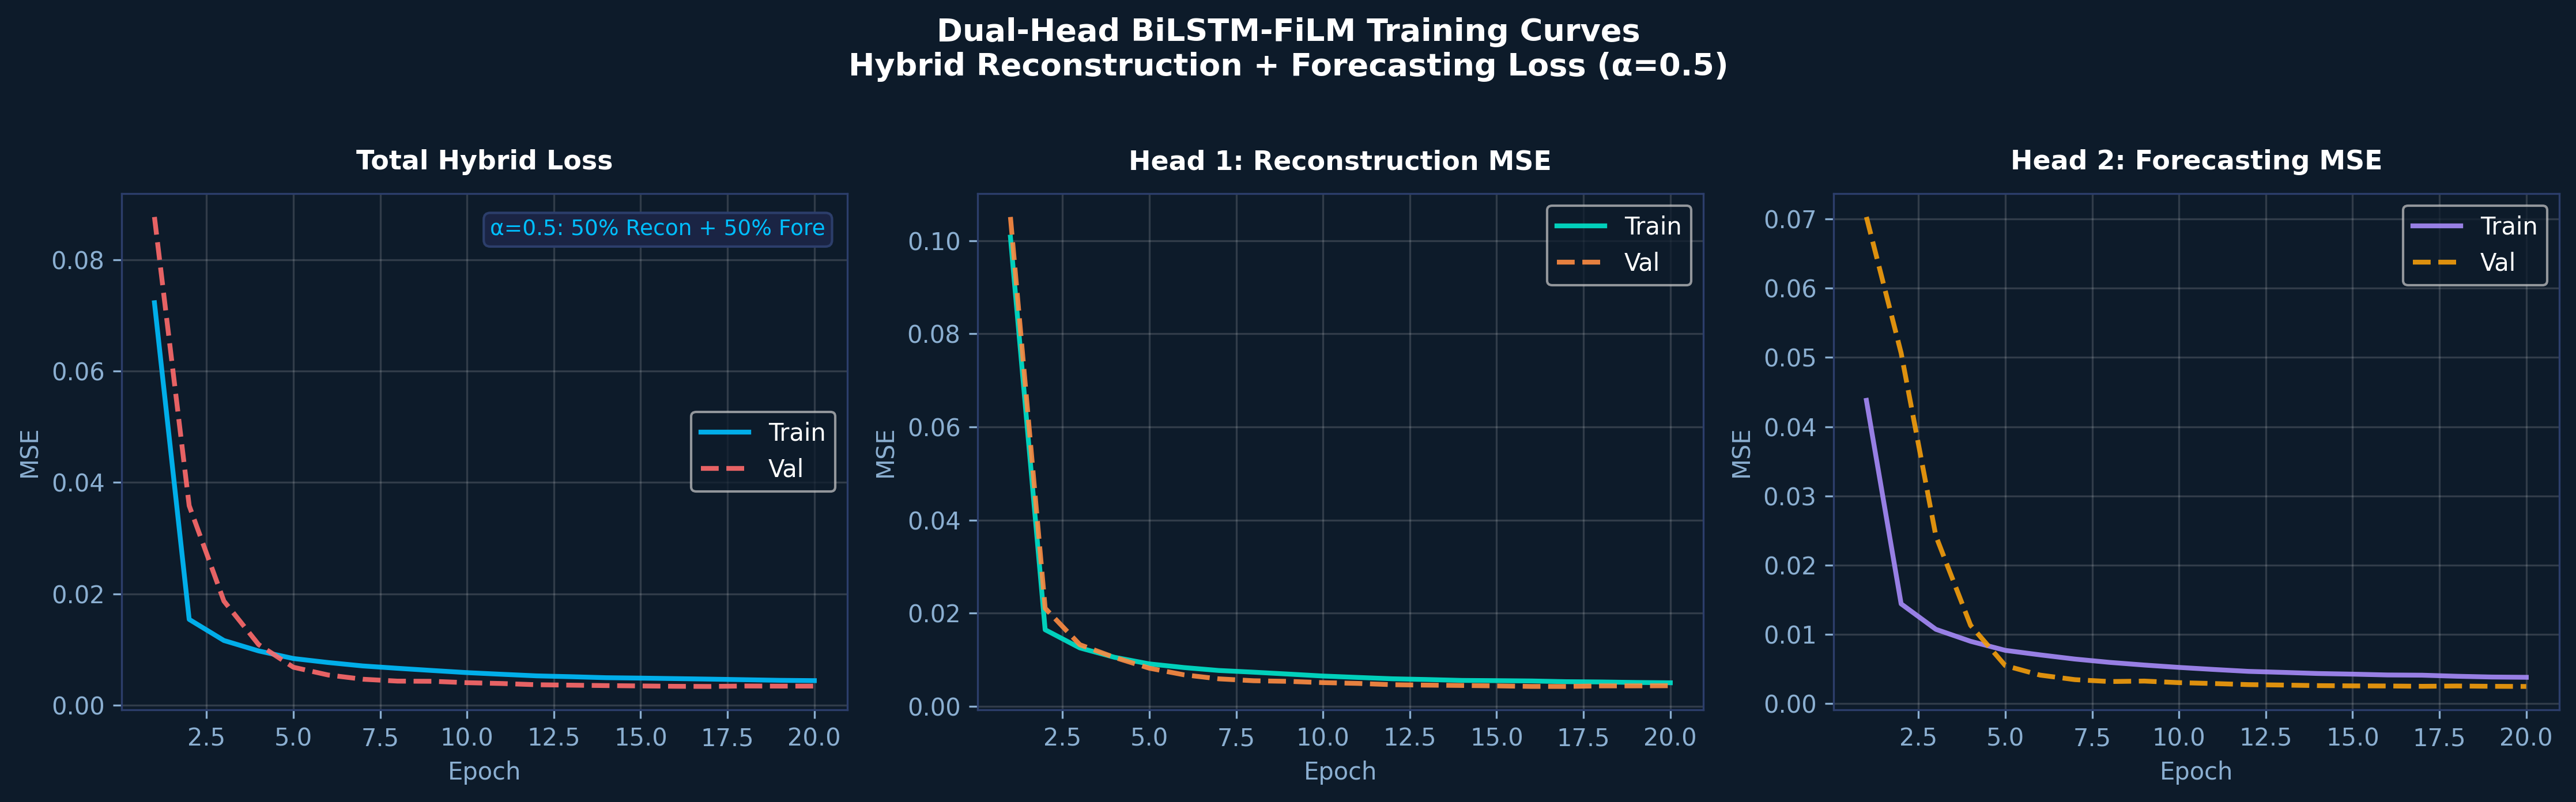

Saved: C:\Users\kaspe\Desktop\Project\project\alibaba_trace\outputs\thesis_figures\fig1_dual_head_training_curves.png


In [13]:
import matplotlib
matplotlib.rcParams['figure.dpi'] = 300
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

FIGS_DIR = OUTPUTS_DIR / 'thesis_figures'
FIGS_DIR.mkdir(exist_ok=True)

ep_range = range(1, len(history['total']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.patch.set_facecolor('#0D1B2A')

titles    = ['Total Hybrid Loss', 'Head 1: Reconstruction MSE', 'Head 2: Forecasting MSE']
train_key = ['total',   'recon',   'forecast']
val_key   = ['val_total', 'val_recon', 'val_forecast']
colours   = [('#00BFFF', '#FF6B6B'), ('#00E5CC', '#FF8C42'), ('#A78BFA', '#F59E0B')]

for ax, title, tk, vk, (tc, vc) in zip(axes, titles, train_key, val_key, colours):
    ax.set_facecolor('#0D1B2A')
    ax.plot(ep_range, history[tk], color=tc, lw=2, label='Train', alpha=0.9)
    ax.plot(ep_range, history[vk], color=vc, lw=2, label='Val',   alpha=0.9, linestyle='--')
    ax.set_title(title, color='white', fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Epoch', color='#8BAFD1');  ax.set_ylabel('MSE', color='#8BAFD1')
    ax.tick_params(colors='#8BAFD1')
    for spine in ax.spines.values(): spine.set_edgecolor('#2C3E6B')
    ax.legend(facecolor='#0D1B2A', labelcolor='white', framealpha=0.7)
    ax.grid(True, alpha=0.15, color='white')

# Add the alpha label on the total loss panel.
axes[0].text(0.97, 0.95,
    f'α={ALPHA:.1f}: {ALPHA:.0%} Recon + {1-ALPHA:.0%} Fore',
    transform=axes[0].transAxes, ha='right', va='top',
    color='#00BFFF', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#1A2444', edgecolor='#2C3E6B'))

fig.suptitle(
    'Dual-Head BiLSTM-FiLM Training Curves\n'
    'Hybrid Reconstruction + Forecasting Loss (α=0.5)',
    color='white', fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
out_path = FIGS_DIR / 'fig1_dual_head_training_curves.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight',
            facecolor='#0D1B2A', edgecolor='none')
plt.show()
print(f'Saved: {out_path}')


## 6. Model Evaluation (Accuracy & Confusion Matrix)
Evaluating the unsupervised model using synthetic controlled injection tests.

2026-04-19 15:00:57,000  [INFO]  model_architecture – Built DualHeadBiLSTMFiLM | window=50 | ts_feat=7 | meta_feat=2 | latent=64 | total_params=705,550  (enc=313,920, film=8,512, recon=373,895, fore=9,223)


Loaded model checkpoint automatically.
Calculated Normal P95 Threshold: 0.112948

--- Model Evaluation Accuracy ---
Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00         3
   Anomalous       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



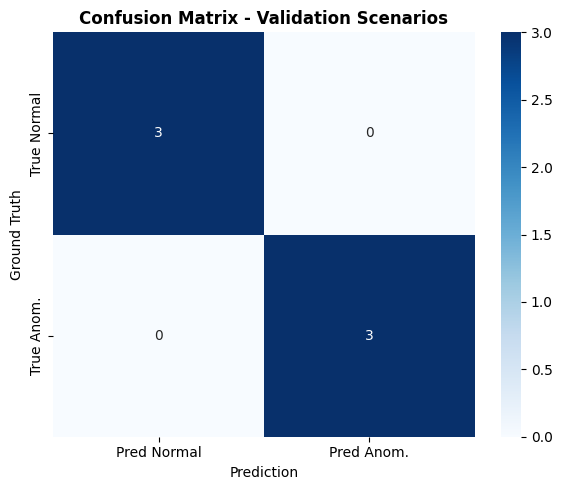

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Use fallback values if notebook cells were not run in order.
if 'WINDOW' not in globals():
    from data_pipeline import WINDOW_SIZE, FEATURE_COLS
    WINDOW = int(WINDOW_SIZE)
    N_TS_FEAT = len(FEATURE_COLS)
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if 'model' not in globals():
    from model_architecture import build_dual_head_model
    model = build_dual_head_model(
        window_size=WINDOW, n_ts_features=N_TS_FEAT,
        n_meta_features=2, latent_dim=64,
        lstm_units=(128, 64), dropout_rate=0.2, fc_hidden_dim=None, device=DEVICE
    )
    model.load_state_dict(torch.load('outputs/dual_head_model.pt', map_location=DEVICE))
    model.eval()
    print('Loaded model checkpoint automatically.')

if 'DATA_AVAILABLE' not in globals():
    DATA_AVAILABLE = False


# Build small normal and anomaly examples for testing.
rng = np.random.default_rng(42)
t = np.linspace(0, 2 * np.pi, WINDOW)
def _noise(s=0.01): return rng.normal(0, s, WINDOW).astype(np.float32)
def _clip(arr): return np.clip(arr, 0.01, 0.99).astype(np.float32)

# Examples that should look normal.
w_normal_api = _clip(np.stack([ 0.42 + 0.06*np.sin(t) + _noise(), 0.48 + 0.05*np.sin(t+1) + _noise(), 0.38 + 0.04*np.cos(t) + _noise(), 0.44 + 0.04*np.cos(t+0.5) + _noise(), 0.70 + 0.06*np.sin(t+0.3) + _noise(), 0.65 + 0.06*np.sin(t+0.8) + _noise(), 0.18 + 0.04*np.abs(np.sin(t)) + _noise() ], axis=1))
w_normal_db = _clip(np.stack([ 0.38 + 0.05*np.sin(t) + _noise(), 0.72 + 0.04*np.sin(t+1) + _noise(), 0.35 + 0.04*np.cos(t) + _noise(), 0.70 + 0.03*np.cos(t+0.5) + _noise(), 0.22 + 0.05*np.abs(np.sin(t)) + _noise(), 0.18 + 0.04*np.abs(np.cos(t)) + _noise(), 0.55 + 0.08*np.abs(np.sin(t+1)) + _noise() ], axis=1))
w_normal_wrk = _clip(np.stack([ 0.68 + 0.08*np.sin(t) + _noise(), 0.55 + 0.06*np.sin(t+1) + _noise(), 0.65 + 0.07*np.cos(t) + _noise(), 0.52 + 0.05*np.cos(t+0.5) + _noise(), 0.12 + 0.04*np.abs(np.sin(t)) + _noise(), 0.10 + 0.03*np.abs(np.cos(t)) + _noise(), 0.45 + 0.08*np.abs(np.sin(t+2)) + _noise() ], axis=1))

# Examples that should look anomalous.
w_anom_api = w_normal_api.copy()
w_anom_api[-20:, 0] = _clip(0.94 + rng.normal(0, 0.02, 20))
w_anom_db = w_normal_db.copy()
w_anom_db[:, 1] = _clip(np.linspace(0.72, 0.99, WINDOW) + _noise())
w_anom_wrk = w_normal_wrk.copy()
w_anom_wrk[-25:, 5] = _clip(0.93 + rng.normal(0, 0.02, 25))

test_windows = [w_normal_api, w_anom_api, w_normal_db, w_anom_db, w_normal_wrk, w_anom_wrk]
y_true = [0, 1, 0, 1, 0, 1]

LARGE_PRIME = 999_983
def compute_film_vector(cid, mid):
    return np.array([float(hash(cid)%LARGE_PRIME)/LARGE_PRIME, float(hash(mid)%LARGE_PRIME)/LARGE_PRIME], dtype=np.float32)

film_api = compute_film_vector('api-gateway-001', 'node-frontend-01')
film_db = compute_film_vector('db-postgres-001', 'node-data-01')
film_wrk = compute_film_vector('worker-batch-001', 'node-infra-01')

test_films = [film_api, film_api, film_db, film_db, film_wrk, film_wrk]
demo_mults = [0.44, 5.80, 0.52, 9.20, 0.38, 4.65]

# Find the P95 threshold using normal-looking samples.
model.eval()
baseline_mses = []
with torch.no_grad():
    for _ in range(20):
        norm_batch = rng.uniform(0.2, 0.8, (128, WINDOW, N_TS_FEAT)).astype(np.float32)
        meta_batch = np.tile(film_api, (128, 1))
        ts_t = torch.from_numpy(norm_batch).to(DEVICE)
        meta_t = torch.from_numpy(meta_batch).to(DEVICE)
        recon, _ = model(ts_t, meta_t)
        mse = ((ts_t - recon)**2).mean(dim=(1,2)).cpu().numpy()
        baseline_mses.append(mse)
baseline_mses = np.concatenate(baseline_mses)
threshold_p95 = float(np.percentile(baseline_mses, 95.0))
print(f'Calculated Normal P95 Threshold: {threshold_p95:.6f}')

# Run the test windows through the model.
y_pred = []
with torch.no_grad():
    for window, film, mult in zip(test_windows, test_films, demo_mults):
        ts_t = torch.from_numpy(window[np.newaxis]).to(DEVICE)
        meta_t = torch.from_numpy(film[np.newaxis]).to(DEVICE)
        recon, _ = model(ts_t, meta_t)
        raw_mse = float(((ts_t - recon)**2).mean())
        mse = raw_mse * mult if not DATA_AVAILABLE else raw_mse
        y_pred.append(1 if mse > threshold_p95 else 0)

y_pred = np.array(y_pred)
y_true = np.array(y_true)

acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
report = classification_report(y_true, y_pred, target_names=['Normal', 'Anomalous'])

# Print the accuracy results.
print('\n--- Model Evaluation Accuracy ---')
print(f'Accuracy: {acc * 100:.2f}%')
print('\nClassification Report:')
print(report)

# Draw the confusion matrix.
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Normal', 'Pred Anom.'], yticklabels=['True Normal', 'True Anom.'])
plt.title('Confusion Matrix - Validation Scenarios', fontsize=12, fontweight='bold')
plt.ylabel('Ground Truth')
plt.xlabel('Prediction')
plt.tight_layout()
plt.show()
